# Prior Sensitivity Analysis in R

## Overview

Prior sensitivity analysis systematically examines how much posterior conclusions change when priors change. It is not optional — it is a required component of any credible applied Bayesian analysis, and is increasingly demanded by reviewers.

**Why it matters:**
- With abundant data, the likelihood dominates and priors have little influence — results should be robust
- With sparse data, priors can strongly influence the posterior — sensitivity must be reported
- A result that holds across a range of reasonable priors is more credible than one that depends on a specific prior choice

**What to vary:**

| Prior class | What to vary | Typical range |
|---|---|---|
| **Regression coefficients** | Width (scale) of the prior | Tight: Normal(0,1); moderate: Normal(0,5); wide: Normal(0,10) |
| **Variance/SD parameters** | Prior family and scale | Exponential(1), Half-Normal(0,1), Half-Cauchy(0,1) |
| **Group-level SD (hierarchical)** | Scale of hyperprior | Exponential(1), Exponential(0.5), Half-Normal(0,2) |
| **Prior location** | Mean shift | Centre at 0 vs. domain-informed value |

**Interpreting results:**
- Posterior nearly identical across priors → results are data-driven and robust
- Posterior shifts substantially → flag the sensitivity and explain which prior is most justified on domain grounds

---

## Setup

In [2]:
library(tidyverse)
library(ggplot2)
library(brms)
library(tidybayes)
library(patchwork)

set.seed(42)

# ── Two datasets: large n and small n (different sensitivity expected) ─────────
make_data <- function(n) {
  tibble(
    nitrate  = rnorm(n, 3, 1),
    richness = pmax(round(22 - 2.5 * nitrate + rnorm(n, 0, 3)), 1)
  )
}

data_large <- make_data(150)   # data-rich: prior should matter little
data_small <- make_data(15)    # data-sparse: prior will matter more

cat("Data-rich n:",  nrow(data_large), "| Data-sparse n:", nrow(data_small), "\n")

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'brms' was built under R version 4.4.3"
Loading required package: Rcpp

Loading 'brms' package (version 2.2

Data-rich n: 150 | Data-sparse n: 15 


---

## Define Prior Grid

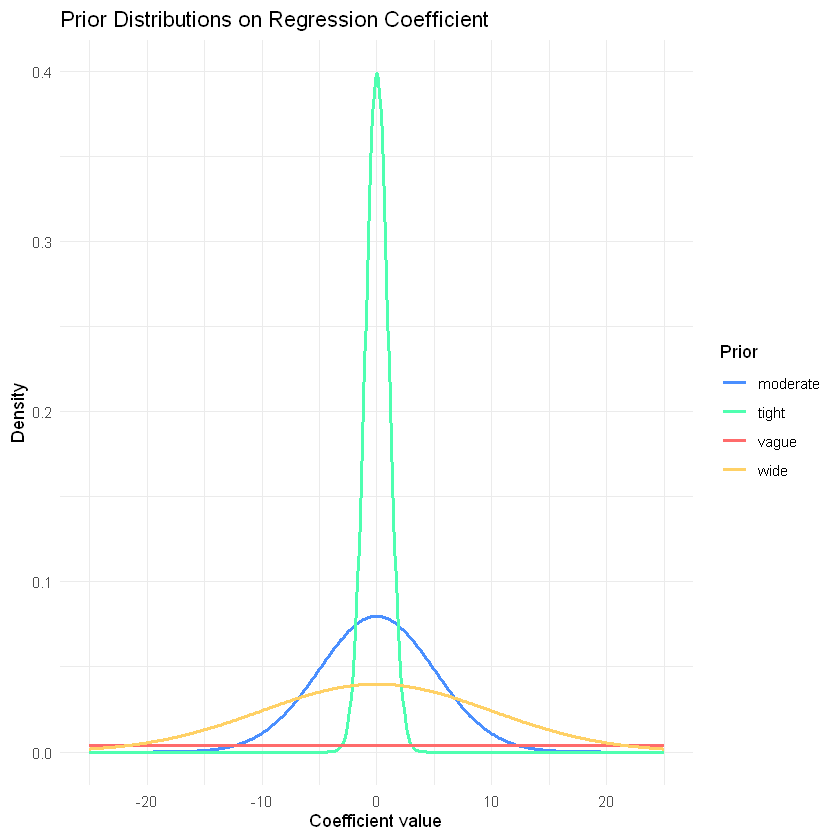

In [3]:
# ── Prior specifications to compare ───────────────────────────────────────────
prior_specs <- list(
  tight = c(
    prior(normal(20, 3),   class = Intercept),
    prior(normal(0, 1),    class = b),           # very tight: SD = 1
    prior(exponential(1),  class = sigma)
  ),
  moderate = c(
    prior(normal(20, 10),  class = Intercept),
    prior(normal(0, 5),    class = b),           # moderate: SD = 5
    prior(exponential(1),  class = sigma)
  ),
  wide = c(
    prior(normal(20, 20),  class = Intercept),
    prior(normal(0, 10),   class = b),           # wide: SD = 10
    prior(exponential(1),  class = sigma)
  ),
  vague = c(
    prior(normal(0, 100),  class = Intercept),
    prior(normal(0, 100),  class = b),           # very vague (nearly flat)
    prior(exponential(0.1), class = sigma)
  )
)

# Visualise the priors on the coefficient scale
prior_df <- map_dfr(names(prior_specs), function(nm) {
  b_prior <- prior_specs[[nm]][prior_specs[[nm]]$class == "b", ]
  # Extract second number from "normal(0, 1)" — the SD
  sd_val  <- as.numeric(str_extract(b_prior$prior, "(?<=,\\s)[0-9.]+(?=\\))"))
  tibble(
    prior_name = nm,
    x          = seq(-25, 25, length.out = 500),
    density    = dnorm(x, 0, sd_val)
  )
})

ggplot(prior_df, aes(x = x, y = density, color = prior_name)) +
  geom_line(linewidth = 1) +
  scale_color_manual(
    values = c(tight = "#4fffb0", moderate = "#4a8fff", wide = "#ffd166", vague = "#ff6b6b")
  ) +
  labs(title = "Prior Distributions on Regression Coefficient",
       x = "Coefficient value", y = "Density", color = "Prior") +
  theme_minimal()

---

## Fit Models Across Prior Grid

In [4]:
fit_with_prior <- function(data, prior, seed = 42) {
  brm(
    richness ~ nitrate,
    data    = data,
    family  = gaussian(),
    prior   = prior,
    chains  = 4, iter = 2000, warmup = 1000,
    cores   = 4, seed = seed, silent = 2
  )
}

# Fit all prior × dataset combinations
fits_large <- map(prior_specs, fit_with_prior, data = data_large)
fits_small <- map(prior_specs, fit_with_prior, data = data_small)

cat("All models fitted.\n")

All models fitted.


---

## Extract and Compare Posterior Summaries

In [5]:
extract_nitrate_posterior <- function(fits, dataset_label) {
  map_dfr(names(fits), function(nm) {
    draws <- tidybayes::spread_draws(fits[[nm]], b_nitrate)$b_nitrate
    tibble(
      prior      = nm,
      dataset    = dataset_label,
      mean       = mean(draws),
      sd         = sd(draws),
      q2.5       = quantile(draws, 0.025),
      q97.5      = quantile(draws, 0.975),
      p_negative = mean(draws < 0)
    )
  })
}

results <- bind_rows(
  extract_nitrate_posterior(fits_large, "Large (n=150)"),
  extract_nitrate_posterior(fits_small, "Small (n=15)")
) %>%
  mutate(
    prior   = factor(prior, levels = names(prior_specs)),
    across(c(mean, sd, q2.5, q97.5, p_negative), ~round(.x, 3))
  )

print(results)

# Key metrics to compare:
# mean:      point estimate — does it change with prior?
# sd:        posterior uncertainty — does the prior dominate?
# q2.5/q97.5: credible interval width and position
# p_negative: P(effect < 0 | data) — does the conclusion change direction?

# A tibble: 8 × 7
  prior    dataset        mean    sd  q2.5 q97.5 p_negative
  <fct>    <chr>         <dbl> <dbl> <dbl> <dbl>      <dbl>
1 tight    Large (n=150) -2.13 0.236 -2.59 -1.66      1    
2 moderate Large (n=150) -2.24 0.238 -2.71 -1.77      1    
3 wide     Large (n=150) -2.25 0.241 -2.73 -1.78      1    
4 vague    Large (n=150) -2.24 0.246 -2.73 -1.77      1    
5 tight    Small (n=15)  -1.63 0.791 -3.12  0.04      0.973
6 moderate Small (n=15)  -3.40 0.996 -5.36 -1.44      1    
7 wide     Small (n=15)  -3.52 0.994 -5.48 -1.46      1    
8 vague    Small (n=15)  -3.59 1.10  -5.82 -1.40      1    


---

## Sensitivity Plot

Warning message:
"The `fatten` argument of `geom_pointrange()` is deprecated as of ggplot2 4.0.0.
ℹ Please use the `size` aesthetic instead."


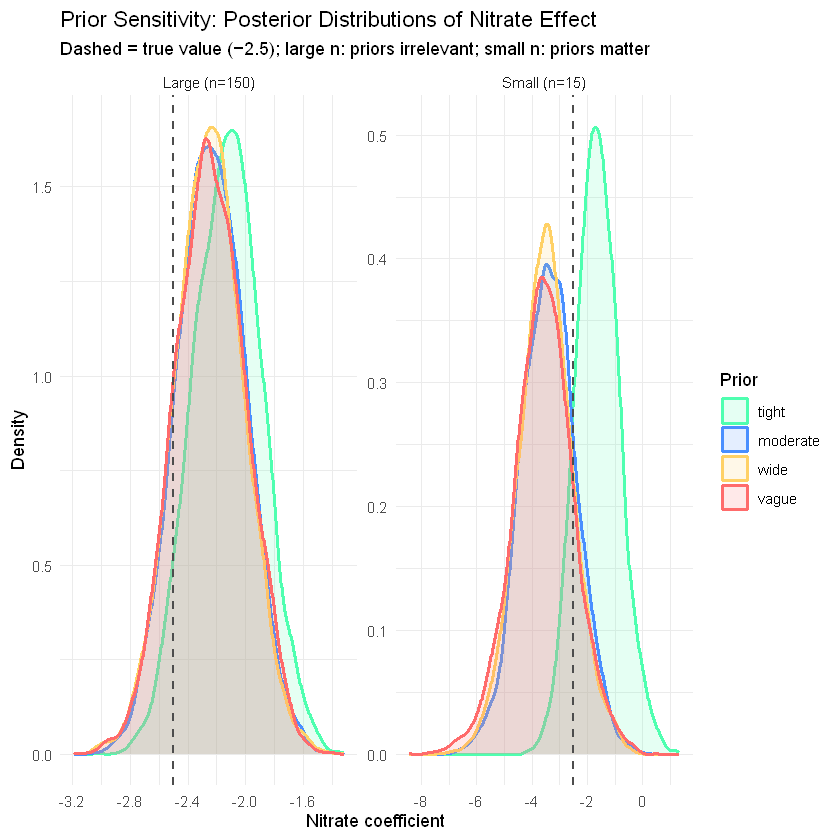

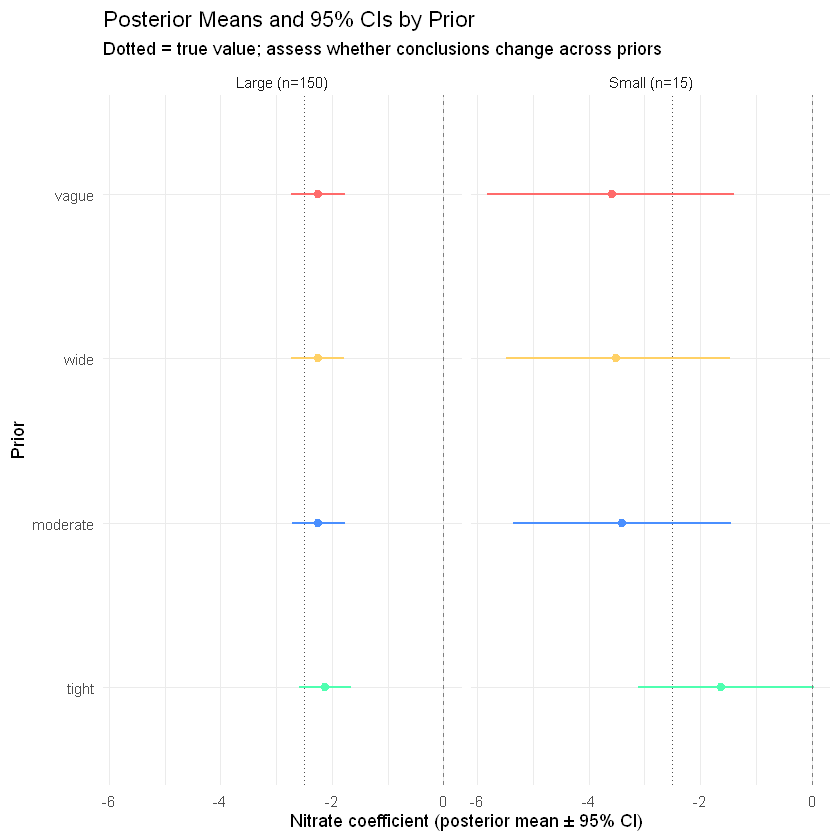

In [6]:
# ── Posterior density overlay ─────────────────────────────────────────────────
posterior_draws <- bind_rows(
  map_dfr(names(fits_large), function(nm) {
    tibble(
      prior   = nm,
      dataset = "Large (n=150)",
      b_nitrate = tidybayes::spread_draws(fits_large[[nm]], b_nitrate)$b_nitrate
    )
  }),
  map_dfr(names(fits_small), function(nm) {
    tibble(
      prior   = nm,
      dataset = "Small (n=15)",
      b_nitrate = tidybayes::spread_draws(fits_small[[nm]], b_nitrate)$b_nitrate
    )
  })
) %>%
  mutate(prior = factor(prior, levels = names(prior_specs)))

pal <- c(tight="#4fffb0", moderate="#4a8fff", wide="#ffd166", vague="#ff6b6b")

ggplot(posterior_draws, aes(x = b_nitrate, color = prior, fill = prior)) +
  geom_density(alpha = 0.15, linewidth = 0.9) +
  geom_vline(xintercept = -2.5, linetype = "dashed",
             color = "gray30", linewidth = 0.8) +
  scale_color_manual(values = pal) +
  scale_fill_manual(values  = pal) +
  facet_wrap(~ dataset, scales = "free") +
  labs(
    title    = "Prior Sensitivity: Posterior Distributions of Nitrate Effect",
    subtitle = "Dashed = true value (−2.5); large n: priors irrelevant; small n: priors matter",
    x = "Nitrate coefficient", y = "Density",
    color = "Prior", fill = "Prior"
  ) +
  theme_minimal()

# ── Coefficient plot: mean + CI across priors ─────────────────────────────────
ggplot(results,
       aes(x = mean, xmin = q2.5, xmax = q97.5, y = prior, color = prior)) +
  geom_pointrange(linewidth = 0.8, fatten = 3) +
  geom_vline(xintercept = 0,    linetype = "dashed", color = "gray50") +
  geom_vline(xintercept = -2.5, linetype = "dotted", color = "gray30") +
  scale_color_manual(values = pal) +
  facet_wrap(~ dataset) +
  labs(
    title    = "Posterior Means and 95% CIs by Prior",
    subtitle = "Dotted = true value; assess whether conclusions change across priors",
    x = "Nitrate coefficient (posterior mean ± 95% CI)", y = "Prior"
  ) +
  theme_minimal() + theme(legend.position = "none")

---

## Sensitivity of the Hyperprior in Hierarchical Models

In [7]:
# In hierarchical models, the SD hyperprior is often the most sensitive choice
# because it controls the degree of shrinkage

n_groups <- 12; n_per_group <- 6
hier_data <- tibble(
  group     = rep(1:n_groups, each = n_per_group),
  x         = rnorm(n_groups * n_per_group),
  group_eff = rep(rnorm(n_groups, 0, 3), each = n_per_group),
  y         = 10 + group_eff + 2 * x + rnorm(n_groups * n_per_group, 0, 2)
) %>%
  mutate(group = factor(group))

sd_priors <- list(
  tight_sd    = prior(exponential(2),   class = sd),  # tight: E[sd] = 0.5
  moderate_sd = prior(exponential(1),   class = sd),  # moderate: E[sd] = 1
  wide_sd     = prior(normal(0, 5),     class = sd)   # wide: half-normal(0,5)
  # normal(0,5) on sd class = half-normal because sd is constrained > 0
)

hier_fits <- map(names(sd_priors), function(nm) {
  brm(
    y ~ x + (1 | group),
    data   = hier_data, family = gaussian(),
    prior  = c(
      prior(normal(10, 5),  class = Intercept),
      prior(normal(0, 3),   class = b),
      prior(exponential(1), class = sigma),
      sd_priors[[nm]]
    ),
    chains = 4, iter = 2000, warmup = 1000, cores = 4,
    seed = 42, silent = 2
  )
}) %>% setNames(names(sd_priors))

# Compare estimated group SD across hyperpriors
map_dfr(names(hier_fits), function(nm) {
  draws <- tidybayes::spread_draws(hier_fits[[nm]], sd_group__Intercept)$sd_group__Intercept
  tibble(
    hyperprior = nm,
    sd_mean    = round(mean(draws), 3),
    sd_q2.5    = round(quantile(draws, 0.025), 3),
    sd_q97.5   = round(quantile(draws, 0.975), 3)
  )
}) %>% print()
# If SD estimates are similar across hyperpriors → data inform σ_group well
# If they differ substantially → flag sensitivity; use the most justified prior

# A tibble: 3 × 4
  hyperprior  sd_mean sd_q2.5 sd_q97.5
  <chr>         <dbl>   <dbl>    <dbl>
1 tight_sd       2.28    1.55     3.31
2 moderate_sd    2.53    1.68     3.80
3 wide_sd        2.90    1.80     4.80


---

## Reporting Prior Sensitivity

In [8]:
# Standard reporting format:
# "Prior sensitivity was assessed by refitting the model with tight
#  (Normal(0,1)), moderate (Normal(0,5)), and wide (Normal(0,10)) priors
#  on regression coefficients. The posterior mean and 95% credible interval
#  for the nitrate effect were: tight: X.XX [X.XX, X.XX]; moderate:
#  X.XX [X.XX, X.XX]; wide: X.XX [X.XX, X.XX]. The posterior
#  [was robust / differed by at most XX / changed qualitatively under]
#  alternative prior specifications, [suggesting conclusions are data-
#  driven / indicating that results should be interpreted with caution
#  given the limited sample size and influence of the prior].
#
#  [If sensitive:] The moderate prior Normal(0,5) was selected as the
#  primary specification based on [domain knowledge / literature values /
#  prior predictive checks], and results are presented under this prior."
cat("Reporting template above.\n")

Reporting template above.


---

## Common Pitfalls

**1. Reporting "we used weakly informative priors" without demonstrating it**  
"Weakly informative" is not self-evidently true for any specific prior — it depends on the outcome scale. Always run prior predictive checks (`sample_prior="only"`) and a sensitivity analysis to demonstrate that the priors did not unduly constrain the posterior.

**2. Varying only the width of the prior, not the family**  
Normal priors and Cauchy priors with the same scale behave very differently in the tails. For variance parameters, the difference between `exponential(1)`, `half-Normal(0,1)`, and `half-Cauchy(0,1)` can be substantial with sparse data. Include at least one alternative family in the sensitivity analysis.

**3. Concluding insensitivity with large n without checking small-sample behaviour**  
With n=500, almost any reasonable prior will produce similar posteriors. The sensitivity analysis is most important precisely when n is small. Report sensitivity results prominently when sample size is limited.

**4. Choosing the prior that gives the most significant or smallest credible interval**  
Prior selection should be based on domain knowledge and prior predictive checks, not on which prior produces the preferred result. This is the Bayesian equivalent of p-hacking. The sensitivity analysis should be pre-specified or the primary prior selected before examining posterior results.

**5. Sensitivity-testing only fixed-effect priors in hierarchical models**  
The hyperprior on group-level SD is often the most influential prior in hierarchical models because it controls shrinkage. Always include it in the sensitivity analysis alongside the regression coefficient priors.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*